# Resistive wall mode
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 176088
source = "format/shots"
grid = load_shot("resistive_wall_mode", shot, source=source)
grid["categories"]

### Original labels
Original annotations before class merging or 50 ms aggregation.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from labeler.config import Paths

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
found = False
for stem, path in paths.items():
    rows = pd.read_csv(path)
    rows = rows.loc[rows.SHOT == shot]
    if rows.empty:
        continue
    found = True
    ax.scatter(rows.ONSET_TIME, rows.NTOR, marker="|", s=150, label=stem)
if not found:
    plt.close(fig)
    print(f"No original RWM annotations for shot {shot}")
else:
    ax.set(
        xlabel="Onset time (ms)",
        ylabel="Toroidal mode number",
        title=f"Shot {shot} — original RWM onset annotations",
    )
    ax.legend()
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

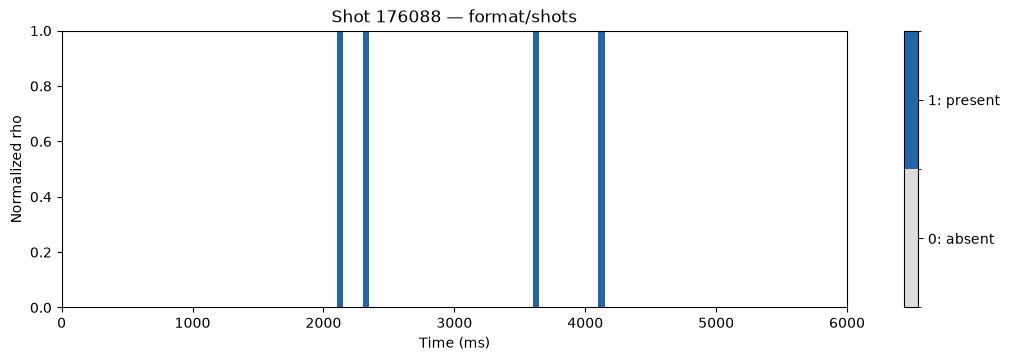

In [3]:
plot_shot(grid);

### Extended labels
The same helper opens extended files. This example shot currently has unknown labels.

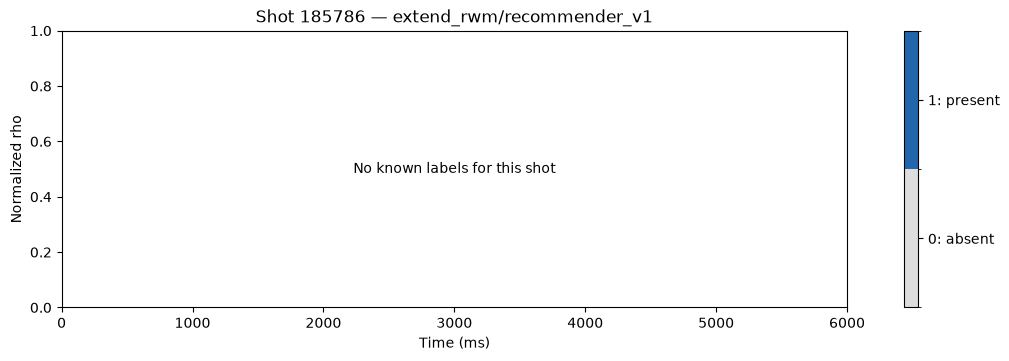

In [4]:
extended = load_shot("resistive_wall_mode", 185786, source="extend_rwm/recommender_v1")
plot_shot(extended);